In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)
# 60,000 張訓練資料(灰階圖)，圖片大小28*28

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [3]:
x_train[0] # 0 黑色，255 白色

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

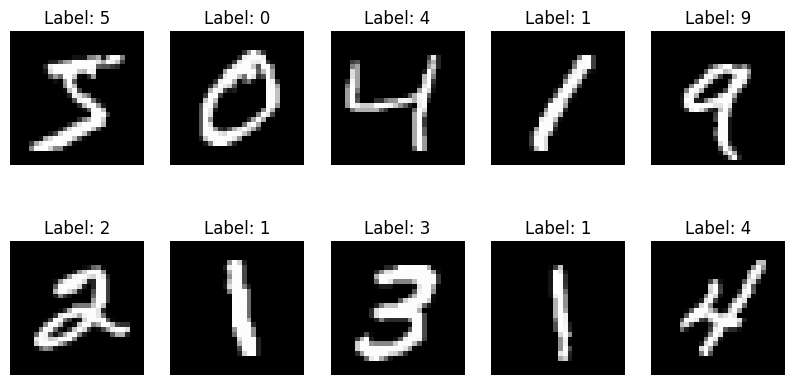

In [4]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

In [5]:
model = tf.keras.models.Sequential([
    # Flatten、Pooling、Dropout、Activation 沒有可學參數，所以沒有 bias
    tf.keras.layers.Flatten(input_shape=(28, 28)), # 28 * 28 = 784
    # 只要一層在做「加權計算」，通常會有 bias，所以 Dense 層會有 bias
    tf.keras.layers.Dense(128, activation='relu'), # 784 inputs * 128 Neurons + 128 bias
    tf.keras.layers.Dense(64, activation='relu'), # 128 inputs * 64 Neurons + 64 bias
    tf.keras.layers.Dense(64, activation='relu'), # 64 inputs * 64 Neurons + 64 bias
    tf.keras.layers.Dense(32, activation='relu'), # 64 inputs * 32 Neurons + 32 bias
    tf.keras.layers.Dense(10, activation='softmax') # 32 inputs * 10 Neurons + 10 bias
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,306 (450.41 KB)

 Trainable params: 115,306 (450.41 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    x_train, 
    y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8399 - loss: 1.0059 - val_accuracy: 0.9307 - val_loss: 0.2381
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9332 - loss: 0.2413 - val_accuracy: 0.9462 - val_loss: 0.1909
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9480 - loss: 0.1798 - val_accuracy: 0.9562 - val_loss: 0.1606
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9580 - loss: 0.1472 - val_accuracy: 0.9542 - val_loss: 0.1645
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9643 - loss: 0.1233 - val_accuracy: 0.9638 - val_loss: 0.1315
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9661 - loss: 0.1168 - val_accuracy: 0.9578 - val_loss: 0.1826
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9686 - loss: 0.1085 - val_accuracy: 0.9675 - val_loss: 0.1304
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9745 - loss: 0.0863 - val_accuracy: 0.

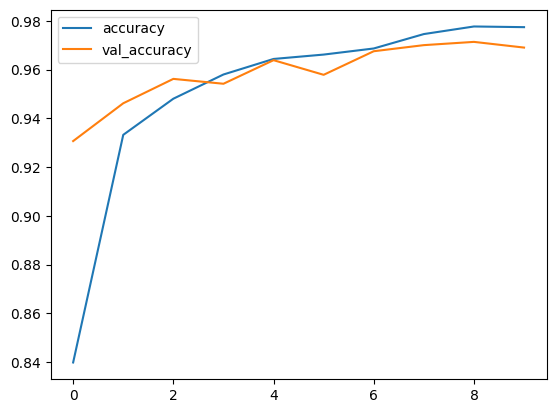

In [7]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()

In [11]:
result = model.predict(x_test)
print(result.shape)
result[0] # 預測 10,000 張圖，每個結果(預測每張圖的結果)用機率來呈現 0~9，機率高的即為預測的結果。

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)


array([1.7445139e-12, 7.9413776e-10, 1.2436669e-09, 9.4020270e-06,
       6.6420367e-12, 7.7497807e-11, 1.6968885e-20, 9.9999022e-01,
       2.2693798e-09, 3.1500764e-07], dtype=float32)

In [13]:
import numpy as np
predictions = np.argmax(result, axis=1) # 取出每個預測結果中，機率最高的落在哪個 index，即為預測的數字。 (index 剛好對應到預測的數值 0~9)
predictions

array([7, 2, 1, ..., 4, 5, 6])